# 02. Quantum field theory at one loop

Loops are where quantum field theory becomes quantum: they give the running couplings, the anomalous magnetic
moment, the Higgs decay to two photons and the corrections that every precision measurement needs. This
notebook goes from the basic one-loop integrals to renormalization and to whole one-loop corrections of
cross sections. Do `01_qft_tree_level.ipynb` first.

**Conventions.** Dimensional regularization with d = 4 − 2ε dimensions. A one-loop integral is written with
the measure μ^{2ε} e^{εγ_E} ∫ dᵈl/(iπ^{d/2}) (the normalization of Package-X and LoopTools, which is the
MS-bar scheme), so the tadpole is A0(m) = m² (1/ε + log(μ²/m²) + 1). Peskin and Schroeder write ε for 4 − d,
so their 2/ε is our 1/ε. Equation and page numbers are from Peskin and Schroeder (pages as printed).

In [1]:
from feynsage import *
from feynsage.models import EL, ME, MM, GS, MW, MZ, SW, CW, MH, MT, MB, SM, QED
from feynsage.qft import tensors as T

## 1. The one-loop functions A0, B0, C0, D0

Every one-loop amplitude can be written with four scalar functions: the tadpole A0, the bubble B0, the
triangle C0 and the box D0. `eps` is ε and `mu` is the scale μ.

In [2]:
m, s = var('m s')
show(A0(m))
show(B0(s, m, m))

m^2*(1/eps + log(mu^2/m^2) + 1)

1/eps + DiscB(s, m, m) + log(mu^2/m^2) + 2

`DiscB` is the bubble's discontinuity function, as in Package-X. The bubble becomes complex above the
threshold s = 4m², where a real pair can be made. Its imaginary part there is πβ with β = √(1 − 4m²/s):

In [3]:
for sv in [3, 5, 10, 100]:
    val = finite_part(B0(sv, 1, 1), 1).n(digits=15)
    beta = sqrt(1 - 4/sv) if sv > 4 else 0
    print("s = %3d:  B0 = %s    pi*beta = %.12f" % (sv, val, (pi*beta).n()))

s =   3:  B0 = 0.790800423843850    pi*beta = 0.000000000000
s =   5:  B0 = 1.56959105903600 + 1.40496294620815*I    pi*beta = 1.404962946208
s =  10:  B0 = 0.401668519244090 + 2.43346720558417*I    pi*beta = 2.433467205584
s = 100:  B0 = -2.49223028849714 + 3.07811959238847*I    pi*beta = 3.078119592388


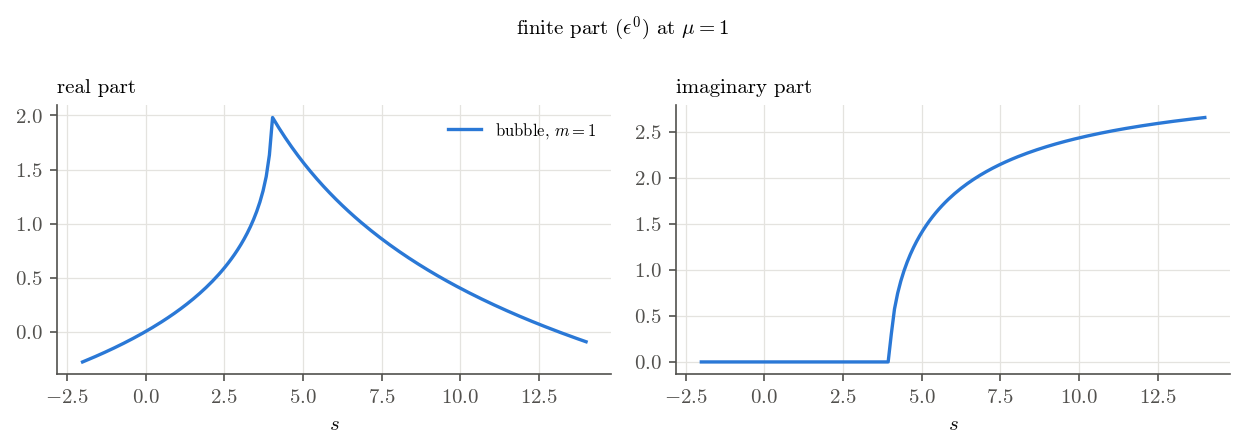

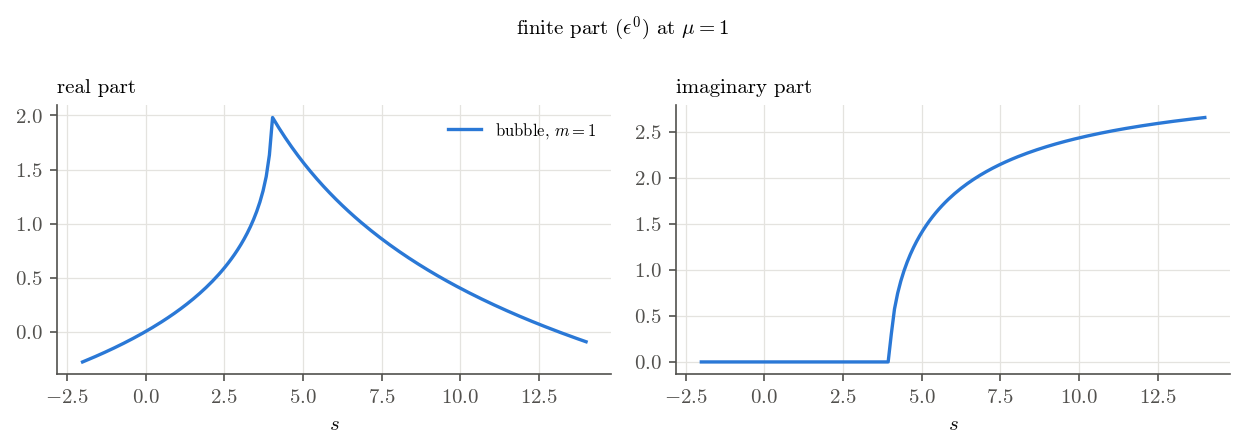

In [4]:
from feynsage.plotting import quick_plot, set_theme
set_theme()
fig = quick_plot([B0(s, 1, 1)], (s, -2, 14), labels=["bubble, $m = 1$"])
fig

Triangles and boxes. Without infrared divergences they stay as the symbols `C0(...)` and `D0(...)`, which
give their value to any precision with `.n()`; `explicit` writes them in dilogarithms.

In [5]:
c = C0(1, 2, 3, 1, 1, 1)
print(c, "=", c.n(digits=30))
d = D0(1, 1, 1, 1, 10, -3, 1, 1, 1, 1)
print(d, "=", d.n(digits=30))

C0(1, 2, 3, 1, 1, 1) = -1.11788759991474371274139695429
D0(1, 1, 1, 1, 10, -3, 1, 1, 1, 1) = -0.0563745663585588535798294260429 + 0.248314556707837458325622386362*I


With massless lines and on-shell legs the integral has infrared poles; feynsage uses the list of Ellis and
Zanderighi (2008). The massless triangle with one off-shell leg:

In [6]:
C0(0, s, 0, 0, 0, 0)

-1/12*pi^2/s + 1/2*LogM(-s)^2/s - LogM(-s)*log(mu^2)/s + 1/2*log(mu^2)^2/s - (LogM(-s)/s - log(mu^2)/s)/eps + 1/(eps^2*s)

## 2. Tensor integrals: `loop`

`loop(numerator, propagator, propagator, ...)` reduces any one-loop integral to A0, B0, C0, D0
(Passarino–Veltman reduction). A propagator is `["l + p", "m"]`, the loop momentum is `l`, and `kin` gives the
external scalar products. The answer comes with its tensor structures:

In [7]:
r = loop("l^mu l^nu", ["l", "m1"], ["l + p", "m2"], kin={"p^2": "s"})
r

g^{mu nu} :  1/12*(m1^2 - m2^2 + s)*m1^2*(1/eps + log(mu^2/m1^2) + 1)/s - 1/12*(m1^2 - m2^2 - s)*m2^2*(1/eps + log(mu^2/m2^2) + 1)/s + 1/18*(m1^2 - m2^2 + s)*m1^2/s - 1/18*(m1^2 - m2^2 - s)*m2^2/s + 1/24*(m1^4 - 2*m1^2*m2^2 + m2^4 - 2*m1^2*s - 2*m2^2*s + s^2)*((m1^2 - m2^2 + s)*log(m1^2/m2^2)/s - 2/eps - 2*DiscB(s, m1, m2) - 2*log(mu^2/m2^2) - 4)/s - 1/18*(m1^4 - 2*m1^2*m2^2 + m2^4 - 2*m1^2*s - 2*m2^2*s + s^2)/s
p^mu p^nu :  -1/3*(m1^2 - m2^2 + s)*m1^2*(1/eps + log(mu^2/m1^2) + 1)/s^2 + 1/3*(m1^2 - m2^2 + 2*s)*m2^2*(1/eps + log(mu^2/m2^2) + 1)/s^2 - 1/18*(m1^2 - m2^2 + s)*m1^2/s^2 + 1/18*(m1^2 - m2^2 - s)*m2^2/s^2 - 1/6*(m1^4 - 2*m1^2*m2^2 + m2^4 + m1^2*s - 2*m2^2*s + s^2)*((m1^2 - m2^2 + s)*log(m1^2/m2^2)/s - 2/eps - 2*DiscB(s, m1, m2) - 2*log(mu^2/m2^2) - 4)/s^2 + 1/18*(m1^4 - 2*m1^2*m2^2 + m2^4 - 2*m1^2*s - 2*m2^2*s + s^2)/s^2

In [8]:
loop("l.p", ["l", "m"], ["l + p", "m"], kin={"p^2": "s"})

1 :  -1/2*s*(1/eps + DiscB(s, m, m) + log(mu^2/m^2) + 2)

## 3. One-loop diagrams of a model

`insert_fields(topologies(1, n_in, n_out), ...)` makes all one-loop diagrams, like FeynArts. `loop_amplitude`
writes each as an integral, closes the free indices with a *projector* that you give, and reduces it. The
result is M (not iM) as a Laurent series in ε.

### 3.1 The photon self-energy and the running of α

The 1PI photon two-point function is iΠ^{μν} = i(q²g^{μν} − q^μq^ν)Π₂(q²). Contracting with g_{μν} gives
(d − 1)q²Π₂. Peskin's Eq. (7.90), p. 252: the pole is Π₂ = −(e²/12π²)(1/ε).

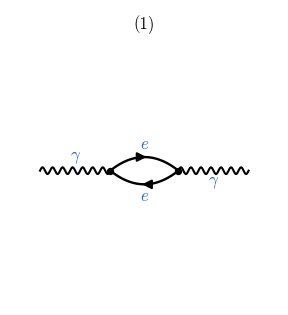

In [9]:
qed = QED(muons=False, taus=False)
q = momenta("q")
Q2 = var('Q2')
se = topologies(1, 1, 1, exclude=('tadpoles', 'wf'))
dA = insert_fields(se, ['A'], ['A'], qed)
dA.draw()

In [10]:
gM = sum(dA.loop_amplitude([q], [q], lambda num, ext: num*T.metric(ext[0], ext[1]), {"q^2": "Q2"}))
Pi2 = gM/((3 - 2*eps)*Q2)
uv_part(Pi2)

-1/12*EL^2/pi^2

The charge renormalization removes Π₂(0); what is left is Π̂₂(q²) = Π₂(q²) − Π₂(0), Peskin's Eq. (7.91), p. 252:

Π̂₂(q²) = −(2α/π) ∫₀¹ dx x(1 − x) log[m²/(m² − x(1 − x)q²)].

We compare at a few q² (with m = 1 and e = 1/3), below and above the threshold q² = 4m²:

In [11]:
def Pi_hat(q2, me=1, e=1/3):                        # with 300-bit numbers: Pi_2(0) comes from a cancellation
    f = lambda x: finite_part(Pi2.subs({Q2: x}), 1).subs({ME: me, EL: e}).n(prec=300)
    return f(q2) - (f(10^-30) + f(-10^-30))/2          # Pi_2(0) from both sides of q^2 = 0

def peskin_791(q2):
    al = (1/3)^2/(4*pi)
    f = lambda y: (y*(1 - y)*log(1/(1 - y*(1 - y)*CDF(q2, 1e-14)))).real()
    g = lambda y: (y*(1 - y)*log(1/(1 - y*(1 - y)*CDF(q2, 1e-14)))).imag()
    return -2*al/pi*(numerical_integral(f, 0, 1)[0] + I*numerical_integral(g, 0, 1)[0])

for q2 in [-10, -1, 2, 10]:
    print("q^2 = %4s   feynsage: %s    Peskin (7.91): %s" % (q2, CDF(Pi_hat(q2)), CDF(peskin_791(q2))))

q^2 =  -10   feynsage: 0.0010121191820787751    Peskin (7.91): 0.0010121191820787754 - 6.110265772581315e-19*I
q^2 =   -1   feynsage: 0.00017007757798023104    Peskin (7.91): 0.00017007757798023104 - 1.5470927752709976e-18*I
q^2 =    2   feynsage: -0.0004926029676368625    Peskin (7.91): -0.0004926029676368626 - 3.3416710512192098e-18*I
q^2 =   10   feynsage: -0.00013947507297437295 - 0.002739575306939999*I    Peskin (7.91): -0.00013947499562381524 - 0.0027395750456773735*I


The effective coupling α_eff(q²) = α/(1 − Π̂₂(q²)) grows at large |q²|: the vacuum polarization screens the
charge. With the measured electron mass, here is α_eff(−Q²) for spacelike Q from 1 MeV to 100 GeV
(electron loop only):

In [12]:
al0 = 1/QQ(137.035999)
me = QQ(0.000511)
def alpha_eff(Q):                       # Q in GeV, q^2 = -Q^2 (spacelike), electron loop only
    val = Pi_hat(-QQ(Q)^2, me=me, e=sqrt(4*pi*al0))
    return al0/(1 - CC(val).real())
for Q in [0.001, 1, 91.19, 1000]:
    print("Q = %8.3f GeV   1/alpha_eff = %.4f" % (Q, 1/alpha_eff(Q)))

Q =    0.001 GeV   1/alpha_eff = 136.9765
Q =    1.000 GeV   1/alpha_eff = 135.6045
Q =   91.190 GeV   1/alpha_eff = 134.6468
Q = 1000.000 GeV   1/alpha_eff = 134.1386


### 3.2 The electron self-energy

The 1PI two-point function of the electron is −iΣ(p) with Σ = A p̸ + B m. feynsage gives M = −Σ; below
`A_` is A and `B_` is B m (the two projections Tr[p̸Σ]/4p² and Tr[Σ]/4). Peskin's
Eq. (10.41), p. 333, written with a photon mass μ; with μ = 0 the same integral is

Σ₂(p) = (e²/16π²) ∫₀¹ dx Γ(ε) e^{γ_E ε} Δ^{−ε} [(4 − 2ε)m − (2 − 2ε)x p̸],  Δ = (1 − x)m² − x(1 − x)p².

Its poles: Σ₂ = (e²/16π²ε)(−p̸ + 4m) + finite.

In [13]:
p = momenta("p")
de = insert_fields(se, ['e'], ['e'], qed)
A_ = -sum(de.loop_amplitude([p], [p], lambda n, e: dirac_trace(slash(p)*n, dim='d')/(4*Q2), {"p^2": "Q2"}))
B_ = -sum(de.loop_amplitude([p], [p], lambda n, e: dirac_trace(n, dim='d')/4, {"p^2": "Q2"}))
show(uv_part(A_)); show(uv_part(B_))

-1/16*EL^2/pi^2

1/4*EL^2*ME/pi^2

The mass counterterm: on shell, δm = Σ₂(p̸ = m) = m(A + B) at p² = m². Its pole is 3e²m/(16π²ε), and below
is its finite part with μ = m (the one-loop shift of the electron mass in the on-shell scheme):

In [14]:
dm = (ME*A_ + B_).subs({Q2: ME^2})        # B_ is already B*m (the trace of the unit part)
show(uv_part(dm))
show(finite_part(dm, ME).simplify_full())

3/16*EL^2*ME/pi^2

1/4*EL^2*ME/pi^2

### 3.3 The magnetic moment of the electron: F₂(0) = α/2π

The vertex correction ū(p₂)Γ^μu(p₁) has the form factors F₁ and F₂. `vertex_projector` gives the Dirac
matrix that picks F₂ out of the vertex by a trace, exactly in d dimensions. F₂(0) = α/2π (Schwinger 1948;
Peskin Eq. (6.58), p. 196):

In [15]:
p1, p2 = momenta("p1 p2")
q2 = var("q2")
def F2_projector(num, ext):
    P = vertex_projector(p1, p2, ME, ext[1], "F2")
    return dirac_trace((slash(p1) + ME)*P*(slash(p2) + ME)*num, dim="d")
vk = {"p1^2": "ME^2", "p2^2": "ME^2", "p1.p2": "ME^2 - q2/2"}
dv = insert_fields(topologies(1, 2, 1, exclude=("tadpoles", "wf")), ["e", "A"], ["e"], qed)
F2 = finite_part(sum(dv.loop_amplitude([p1, p2 - p1], [p2], F2_projector, kin=vk)), 1)/EL
F2_0 = ((F2.subs(q2=10^-10) + F2.subs(q2=-10^-10))/2).subs({EL: sqrt(4*pi/137.035999), ME: 1})
print("F2(0)     =", F2_0.n(digits=15))
print("alpha/2pi =", (1/137.035999/(2*pi)).n(digits=15))

F2(0)     = 0.00116140973359778
alpha/2pi = 0.00116140973359778


F₂ does not depend on the gauge. In R_ξ gauge (`xi=3`) the photon propagator has an extra (1 − ξ)k^μk^ν/k⁴ term,
which changes the self-energy but not F₂:

In [16]:
F2x = finite_part(sum(dv.loop_amplitude([p1, p2 - p1], [p2], F2_projector, kin=vk, xi=3)), 1)/EL
F2x_0 = ((F2x.subs(q2=10^-10) + F2x.subs(q2=-10^-10))/2).subs({EL: sqrt(4*pi/137.035999), ME: 1})
print("xi = 3:  F2(0) =", F2x_0.n(digits=15))
A3 = -sum(de.loop_amplitude([p], [p], lambda n, e: dirac_trace(slash(p)*n, dim='d')/(4*Q2), {"p^2": "Q2"}, xi=3))
print("but the self-energy pole changes with xi:", uv_part(A_), " ->", uv_part(A3))

xi = 3:  F2(0) = 0.00116140973359778
but the self-energy pole changes with xi: -1/16*EL^2/pi^2  -> -3/16*EL^2/pi^2


## 4. Renormalization of QCD and asymptotic freedom

The QCD β function follows from three counterterms (Peskin Eq. (16.73), p. 527):

β(g) = g M ∂/∂M (−δ₁ + δ₂ + ½δ₃),

where δ₃ cancels the pole of the gluon self-energy, δ₂ that of the quark self-energy and δ₁ that of the
quark–gluon vertex. Each δ is c/ε and M∂/∂M acting on it gives −2c. We let feynsage compute all three
from the diagrams, with one quark flavour in the loops (Feynman gauge).

In [17]:
sm = SM()
ALL = ['A','Z','W+','H','G0','G+','u+','u-','uA','uZ','g','ug','e','mu','ta','ne','nm','nt','u','c','t','d','s','b']
only = lambda keep: [f for f in ALL if f not in keep]      # the fields that may not appear inside the loop
a1, a2 = color_indices("a1 a2"); i1, i2, i3 = quark_colors("i1 i2 i3"); a = color_indices("a2")
kin = {"p^2": "Q2"}

# delta_3: the gluon self-energy (gluon loop, ghost loop and a u-quark loop)
dg = insert_fields(se, ['g'], ['g'], sm, exclude_fields=only(('g', 'ug', 'u')))
print(len(dg), "diagrams for the gluon self-energy")
gM = sum(dg.loop_amplitude([p], [p], lambda n, e: n*T.metric(e[0], e[1]), kin)).subs({color_delta(a1, a2): 1})
c3 = (uv_part(gM)/(3*Q2)).simplify_full()

# delta_2: the quark self-energy, Sigma = -M
dq = insert_fields(se, ['u'], ['u'], sm, exclude_fields=only(('g', 'u')))
c2 = (-uv_part(sum(dq.loop_amplitude([p], [p], lambda n, e: dirac_trace(slash(p)*n, dim='d')/(4*Q2), kin)))).subs({color_delta(i1, i2): 1})

# delta_1: the quark-gluon vertex, in units of the tree vertex -g T^a gamma^mu
k1, k2 = momenta("k1 k2")
dv3 = insert_fields(topologies(1, 2, 1, exclude=('tadpoles', 'wf')), ['u', 'g'], ['u'], sm, exclude_fields=only(('g', 'ug', 'u')))
print(len(dv3), "diagrams for the quark-gluon vertex")
Mv = sum(dv3.loop_amplitude([k1, k2 - k1], [k2], lambda n, e: dirac_trace(gamma(e[1])*n, dim='d')/16,
                            {"k1^2": 0, "k2^2": 0, "k1.k2": "-Q2/2"}))
Tc = T_color(a, i1, i3)
c1 = -(color_factor(uv_part(Mv)*Tc, N=3)/color_factor(-GS*T_color(a, i3, i1)*Tc, N=3)).simplify_full()

for name, val in [("delta_1", c1), ("delta_2", c2), ("delta_3", c3)]:
    print(name, "* eps =", val.factor())
beta = (-2*GS*(-c1 + c2 + c3/2)).factor()
beta

4 diagrams for the gluon self-energy


2 diagrams for the quark-gluon vertex


delta_1 * eps = -13/48*GS^2/pi^2
delta_2 * eps = -1/12*GS^2/pi^2
delta_3 * eps = 13/48*GS^2/pi^2


-31/48*GS^3/pi^2

That is β = −(g³/16π²)(11 − 2n_f/3) with n_f = 1, Peskin's Eq. (16.85), p. 531 with C₂(G) = 3, C(r) = 1/2:
QCD is asymptotically free. The coupling then runs as
α_s(Q) = α_s(M_Z)/[1 + α_s(M_Z) b₀ log(Q²/M_Z²)/(4π)] with b₀ = 11 − 2n_f/3:

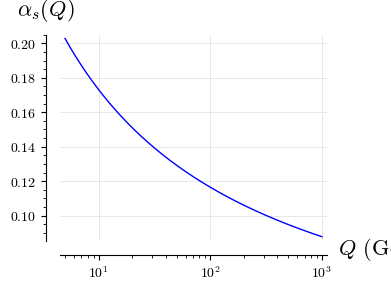

In [18]:
b0 = 11 - 2*5/3                 # five light flavours
alpha_s = lambda Q: 0.118/(1 + 0.118*b0*log(Q^2/91.19^2)/(4*pi))
Q = var('Q')
plot(alpha_s(Q), (Q, 5, 1000), scale='semilogx', axes_labels=['$Q$ (GeV)', r'$\alpha_s(Q)$'], figsize=4)

## 5. Higgs decays through loops: H → gg and H → γγ

The Higgs has no coupling to gluons or photons, but it decays to them through loops. For H → gg only the top
loop matters. Peskin's Final Project III, part (c), p. 777, gives the width through the integral
I(τ) = 3∫₀¹dx∫₀^{1−x}dy (1 − 4xy)/(1 − xyτ), τ = m_h²/m_q² (here done in one variable).

In [19]:
k1, k2 = momenta("k1 k2")
light = ['e', 'mu', 'ta', 'ne', 'nm', 'nt', 'u', 'c', 'd', 's']
dgg = insert_fields(topologies(1, 1, 2, exclude=("tadpoles", "wf")), ["H"], ["g", "g"], sm, exclude_fields=light)
def transverse(num, ext):                 # T_{mu nu} M^{mu nu} = (d - 2)(k1.k2) F
    mu_, nu_ = ext[1], ext[2]
    return num*(T.metric(mu_, nu_) - (T.comp(k2, mu_)*T.comp(k1, nu_) + T.comp(k1, mu_)*T.comp(k2, nu_))/T.dot(k1, k2))
Mgg = sum(dgg.loop_amplitude([k1 + k2], [k1, k2], transverse, {"k1^2": 0, "k2^2": 0, "k1.k2": "MH^2/2"}))
b1, b2 = color_indices("a2 a3")
F_gg = (finite_part(Mgg, 1)/MH^2).subs({color_delta(b1, b2): 1})
print(len(dgg), "diagrams;  the 1/eps pole:", uv_part(Mgg).simplify_full())

4 diagrams;  the 1/eps pole: 0


In [20]:
import mpmath
def I_x(tau):
    tau = mpmath.mpf(float(tau))
    lg = lambda y: mpmath.log(mpmath.mpc(1 - y*(1 - y)*tau, -mpmath.mpf(10)**-40))
    pts = [0, 0.5, 1]
    if tau > 4:
        r = mpmath.sqrt(1 - 4/tau)/2
        pts = [0, 0.5 - r, 0.5, 0.5 + r, 1]
    return complex(3*mpmath.quad(lambda y: 4/tau*(1 - y) - (1 - 4/tau)*lg(y)/(y*tau), pts))
peskin = {EL: sqrt(4*pi/128), SW: sqrt(0.23), CW: sqrt(0.77), MW: 80, MZ: 91, MT: 175, MB: 5, GS: sqrt(4*pi*0.12)}
G_gg = abs(F_gg)^2*MH^3/(8*pi)
def peskin_c(mh):                          # top (175 GeV) and bottom (5 GeV) loops, as in the diagrams
    I = I_x(float(mh^2/175^2)) + I_x(float(mh^2/5^2))
    return float((1/128)*mh/(8*0.23)*mh^2/80^2*0.12^2/(9*pi.n()^2)*abs(complex(I))^2)
for mh in [100, 300, 400]:
    print("m_h = %d GeV:  feynsage %.6e GeV    Peskin's formula %.6e GeV" % (mh, float(G_gg.subs(peskin).subs(MH=mh).n()), peskin_c(mh)))

m_h = 100 GeV:  feynsage 9.678637e-05 GeV    Peskin's formula 9.678637e-05 GeV
m_h = 300 GeV:  feynsage 4.450690e-03 GeV    Peskin's formula 4.450690e-03 GeV


m_h = 400 GeV:  feynsage 2.188169e-02 GeV    Peskin's formula 2.188169e-02 GeV


H → γγ has the W loops as well (with Goldstone bosons and ghosts in Feynman gauge). Each set of diagrams has a
1/ε pole, but the sum is finite:

In [21]:
daa = insert_fields(topologies(1, 1, 2, exclude=("tadpoles", "wf")), ["H"], ["A", "A"], sm,
                    exclude_fields=['e', 'mu', 'ta', 'ne', 'nm', 'nt', 'u', 'c', 'd', 's'])
print(len(daa), "diagrams")
Maa = daa.loop_amplitude([k1 + k2], [k1, k2], transverse, {"k1^2": 0, "k2^2": 0, "k1.k2": "MH^2/2"})
print("pole of the sum:", uv_part(sum(Maa)).simplify_full())

30 diagrams


pole of the sum: 0


## 6. The one-loop correction to a cross section: `virtual()`

For a cross section at one loop we need 2 Re(M₀* M₁), with M₀ the tree amplitude and M₁ the one-loop amplitude,
summed over spins. `process(...).virtual()` does all of it: it makes the one-loop diagrams, works out the Dirac
algebra in d dimensions, reduces the integrals and returns Σ M₀*M₁ (averaged like `squared()`) as a Laurent
series in ε. For e⁺e⁻ → μ⁺μ⁻ in QED with the masses kept there are 7 diagrams: two vertex corrections, three
vacuum polarizations (e, μ, τ loops) and two boxes.

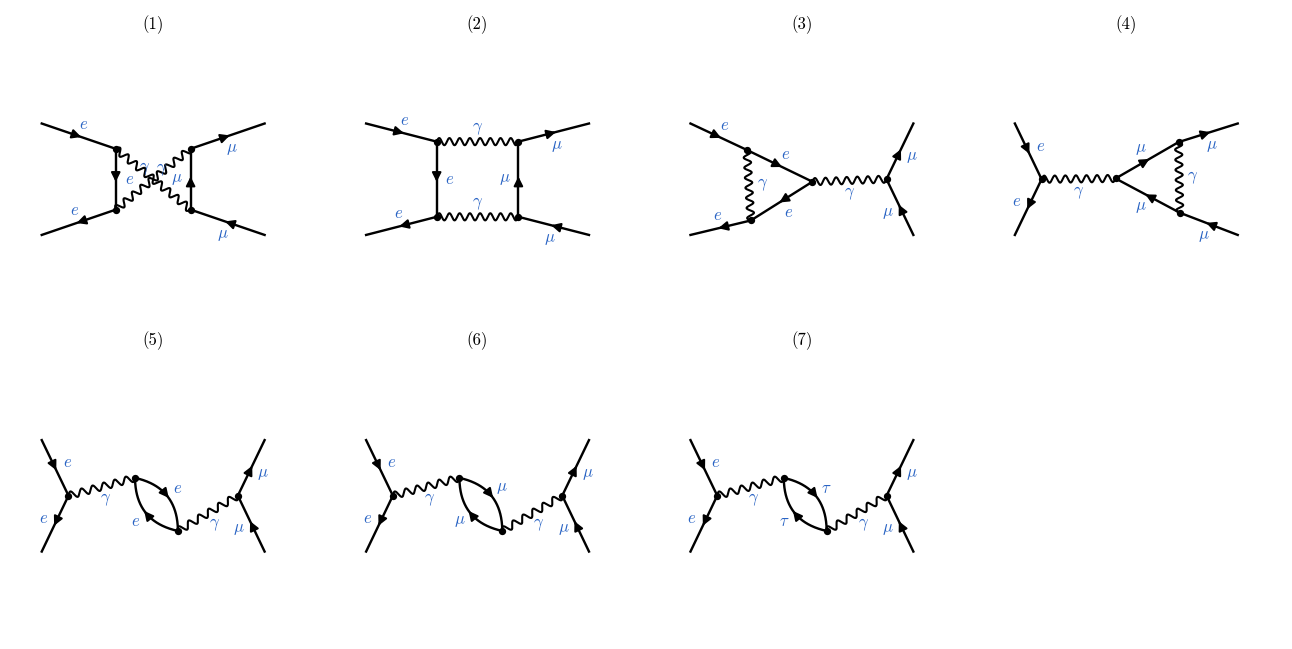

In [22]:
P = process("e- e+ -> mu- mu+", model="QED")
P.loop_diagrams().draw()

In [23]:
V = P.virtual()
pt = {P.s: 30, P.t: -9, EL: 1, ME: 1/2, MM: 1}
from feynsage.models import ML
pt[ML] = 3/2
print("1/eps^2:", SR(pole_parts(V)[0]).subs(pt).n(digits=12))
print("1/eps  :", SR(pole_parts(V)[1]).subs(pt).n(digits=12))
print("finite :", SR(finite_part(V, 1)).subs(pt).n(digits=12))

1/eps^2: 0
1/eps  : 0.0933077384578 - 0.100956569213*I


finite : 0.193587800791 + 0.247636853158*I


The 1/ε pole has two parts. The ultraviolet part is removed by renormalization: the counterterms of section 3
(and the factors of the external legs, which `virtual()` leaves out). The infrared part comes from a virtual
photon of very small energy; it cancels against the emission of a soft real photon (e⁺e⁻ → μ⁺μ⁻γ, which
`process` also computes), as the Bloch–Nordsieck theorem says. There is no 1/ε² pole because the leptons are
massive.

These one-loop results were compared with FeynArts + FeynCalc + Package-X, diagram class by class, poles and
finite parts (`tests/test_feyncalc_loop.sage`), and likewise for H → b b̄ with the gluon loop and for
Z → ν ν̄ with all seven electroweak diagrams.

## 7. Exercises

1. Compute the muon loop contribution to Π̂₂(q²) and check that at |q²| ≪ m_μ² it is suppressed by q²/m_μ².
2. Repeat the calculation of δ₃ with two quark flavours (`only(('g', 'ug', 'u', 'd'))`) and check
   β = −(g³/16π²)(11 − 4/3).
3. Compute F₁(q²) − 1 with `vertex_projector(..., "F1")`: why does it have a 1/ε pole at q² ≠ 0, and which
   pole is it?
4. Use `process("H -> b b~").virtual(...)` with only the gluon diagram to get the QCD correction to Γ(H → b b̄)
   before the real emission.